In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

from myDataset import *
from ArchitectureMethods import *
from MetricMethods import *

In [ ]:
import torchvision.models as models

# Loads model from .pth file

emotionTotal = 7

# Loads MobileNetV2 trained model
mobilenet = models.mobilenet_v2(weights = 'DEFAULT')
mobilenet.classifier = torch.nn.Linear(in_features=1280, out_features= emotionTotal)
mobilenet.load_state_dict(torch.load('CK+ MobileNetV2 copy.pth'))
mobilenet.to('cuda')
mobilenet.eval()

# Loads ResNet18 trained model
resnet18 = models.resnet18(weights = None)
resnet18.fc = nn.Sequential(nn.Linear(resnet18.fc.in_features,emotionTotal))
resnet18.load_state_dict(torch.load('CK+ ResNet18 copy.pth'))
resnet18.to('cuda')
resnet18.eval()

# Loads ResNet34 trained model
resnet34 = models.resnet34(weights = None)
resnet34.fc = nn.Sequential(nn.Linear(resnet34.fc.in_features,emotionTotal))
resnet34.load_state_dict(torch.load('CK+ ResNet34 copy.pth'))
resnet34.to('cuda')
resnet34.eval()

from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, recall_score
os.chdir('/user/HS401/ob00564/Documents/COM3001/CK+')

print(os.getcwd())
CK_dataset = myDataset(directory = "DATASET/test", transform = test_transform)
CK_loader = DataLoader(CK_dataset, batch_size = 32, shuffle = False)

device = 'cuda'
criterion = nn.CrossEntropyLoss()



/tmp/ipykernel_1597190/1796883840.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mobilenet.load_state_dict(torch.load('CK+ MobileNetV2 copy.pth'))
/tmp/ipykernel_15971

/user/HS401/ob00564/Documents/COM3001/CK+


/tmp/ipykernel_1597190/1796883840.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet34.load_state_dict(torch.load('CK+ ResNet34 copy.pth'))


CK SPLIT MobileNetV2
Test Loss: 1.2903, Test Accuracy: 64.52%
Precision: 0.09216589861751152
Recall: 0.14285714285714285
F1: 0.11204481792717087


/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


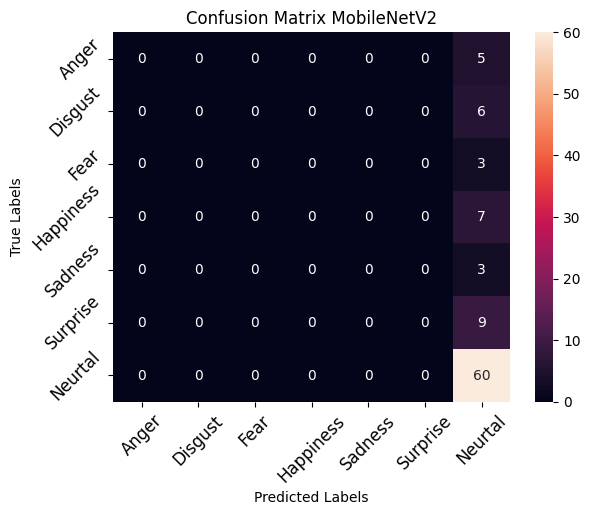

              precision    recall  f1-score   support

       Anger     0.0000    0.0000    0.0000         5
     Disgust     0.0000    0.0000    0.0000         6
        Fear     0.0000    0.0000    0.0000         3
   Happiness     0.0000    0.0000    0.0000         7
     Sadness     0.0000    0.0000    0.0000         3
    Surprise     0.0000    0.0000    0.0000         9
     Neurtal     0.6452    1.0000    0.7843        60

    accuracy                         0.6452        93
   macro avg     0.0922    0.1429    0.1120        93
weighted avg     0.4162    0.6452    0.5060        93



/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [19]:
print('CK SPLIT MobileNetV2')
criterion = nn.CrossEntropyLoss()
CK_y_true, CK_y_pred, CK_y_score = test(mobilenet, device, criterion, CK_loader, 'Test')

precision = precision_score(y_true = CK_y_true, y_pred=CK_y_pred, average='macro')
recall = recall_score(y_true = CK_y_true, y_pred=CK_y_pred, average='macro')
f1score = f1_score(CK_y_true, CK_y_pred, average='macro')
print('Precision: ' + str(precision))
print('Recall: ' + str(recall))
print('F1: ' + str(f1score))
confusionMatrixPlot(CK_y_true, CK_y_pred, 'MobileNetV2')
CK_y_true, CK_y_pred, CK_y_score = None, None, None

/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


CK SPLIT ResNet18
Test Loss: 1.1496, Test Accuracy: 64.52%
Precision: 0.09216589861751152
Recall: 0.14285714285714285
F1: 0.11204481792717087


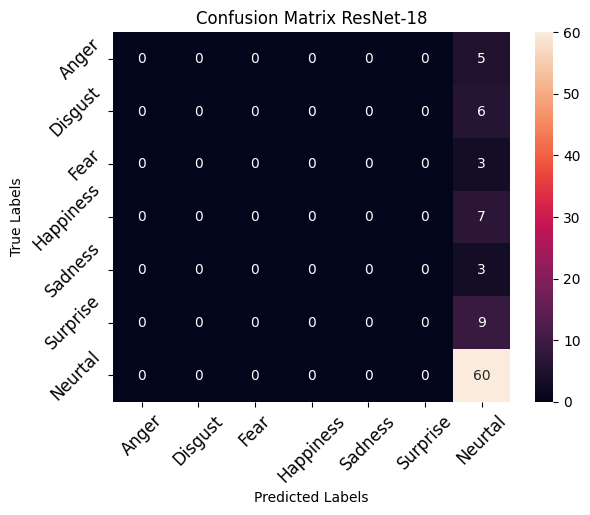

              precision    recall  f1-score   support

       Anger     0.0000    0.0000    0.0000         5
     Disgust     0.0000    0.0000    0.0000         6
        Fear     0.0000    0.0000    0.0000         3
   Happiness     0.0000    0.0000    0.0000         7
     Sadness     0.0000    0.0000    0.0000         3
    Surprise     0.0000    0.0000    0.0000         9
     Neurtal     0.6452    1.0000    0.7843        60

    accuracy                         0.6452        93
   macro avg     0.0922    0.1429    0.1120        93
weighted avg     0.4162    0.6452    0.5060        93



/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [20]:
print('CK SPLIT ResNet18')
criterion = nn.CrossEntropyLoss()
CK_y_true, CK_y_pred, CK_y_score = test(resnet18, device, criterion, CK_loader, 'Test')

precision = precision_score(y_true = CK_y_true, y_pred=CK_y_pred, average='macro')
recall = recall_score(y_true = CK_y_true, y_pred=CK_y_pred, average='macro')
f1score = f1_score(CK_y_true, CK_y_pred, average='macro')
print('Precision: ' + str(precision))
print('Recall: ' + str(recall))
print('F1: ' + str(f1score))
confusionMatrixPlot(CK_y_true, CK_y_pred, 'ResNet-18')
CK_y_true, CK_y_pred, CK_y_score = None, None, None

/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


CK SPLIT ResNet34
Test Loss: 1.1040, Test Accuracy: 65.59%
Precision: 0.2360248447204969
Recall: 0.15873015873015875
F1: 0.14135338345864662


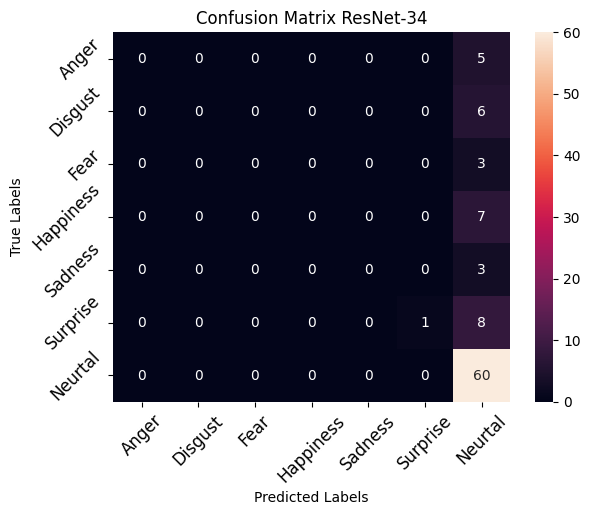

              precision    recall  f1-score   support

       Anger     0.0000    0.0000    0.0000         5
     Disgust     0.0000    0.0000    0.0000         6
        Fear     0.0000    0.0000    0.0000         3
   Happiness     0.0000    0.0000    0.0000         7
     Sadness     0.0000    0.0000    0.0000         3
    Surprise     1.0000    0.1111    0.2000         9
     Neurtal     0.6522    1.0000    0.7895        60

    accuracy                         0.6559        93
   macro avg     0.2360    0.1587    0.1414        93
weighted avg     0.5175    0.6559    0.5287        93



/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [21]:
print('CK SPLIT ResNet34')
criterion = nn.CrossEntropyLoss()
CK_y_true, CK_y_pred, CK_y_score = test(resnet34, device, criterion, CK_loader, 'Test')

precision = precision_score(y_true = CK_y_true, y_pred=CK_y_pred, average='macro')
recall = recall_score(y_true = CK_y_true, y_pred=CK_y_pred, average='macro')
f1score = f1_score(CK_y_true, CK_y_pred, average='macro')
print('Precision: ' + str(precision))
print('Recall: ' + str(recall))
print('F1: ' + str(f1score))
confusionMatrixPlot(CK_y_true, CK_y_pred,'ResNet-34')
CK_y_true, CK_y_pred, CK_y_score = None, None, None

In [22]:
os.chdir('/user/HS401/ob00564/Documents/COM3001/JAFFE')
print(os.getcwd())
jaffe_dataset = myDataset(directory = "DATASET/test", transform = test_transform)
jaffe_loader = DataLoader(jaffe_dataset, batch_size = 32, shuffle = False)

os.chdir('/user/HS401/ob00564/Documents/COM3001/KDEF')
print(os.getcwd())
kdef_dataset = myDataset(directory = "DATASET/test", transform = test_transform)
kdef_loader = DataLoader(kdef_dataset, batch_size = 32, shuffle = False)

/user/HS401/ob00564/Documents/COM3001/JAFFE
/user/HS401/ob00564/Documents/COM3001/KDEF


In [23]:
# Testing KDEF Generalizability on JAFFE using MobileNetV2
os.chdir('/user/HS401/ob00564/Documents/COM3001/JAFFE')
criterion = nn.CrossEntropyLoss()
print('JAFFE SPLIT on MobileNetV2')
JAFFE_y_true, JAFFE_y_pred, JAFFE_y_score = test(mobilenet, device, criterion, jaffe_loader, 'Test')
criterion = nn.CrossEntropyLoss()
print('JAFFE SPLIT on ResNet18')
JAFFE_y_true, JAFFE_y_pred, JAFFE_y_score = test(resnet18, device, criterion, jaffe_loader, 'Test')
criterion = nn.CrossEntropyLoss()
print('JAFFE SPLIT on ResNet34')
JAFFE_y_true, JAFFE_y_pred, JAFFE_y_score = test(resnet34, device, criterion, jaffe_loader, 'Test')

JAFFE SPLIT on MobileNetV2
Test Loss: 2.0379, Test Accuracy: 14.29%
JAFFE SPLIT on ResNet18
Test Loss: 2.9212, Test Accuracy: 14.29%
JAFFE SPLIT on ResNet34
Test Loss: 2.3522, Test Accuracy: 14.29%


In [24]:
os.chdir('/user/HS401/ob00564/Documents/COM3001/KDEF')
criterion = nn.CrossEntropyLoss()
print('KDEF SPLIT MobileNetV2')
KDEF_y_true, KDEF_y_pred, KDEF_y_score = test(mobilenet, device, criterion, kdef_loader, 'Test')
criterion = nn.CrossEntropyLoss()
print('KDEF SPLIT ResNet18')
KDEF_y_true, KDEF_y_pred, KDEF_y_score = test(resnet18, device, criterion, kdef_loader, 'Test')
criterion = nn.CrossEntropyLoss()
print('KDEF SPLIT ResNet34')
KDEF_y_true, KDEF_y_pred, KDEF_y_score = test(resnet34, device, criterion, kdef_loader, 'Test')

KDEF SPLIT MobileNetV2
Test Loss: 2.0341, Test Accuracy: 14.29%
KDEF SPLIT ResNet18
Test Loss: 2.6378, Test Accuracy: 14.29%
KDEF SPLIT ResNet34
Test Loss: 2.2373, Test Accuracy: 14.29%
